**Task**

Implement an Automatic Higher or Lower Game.

Set the bounds to between 1 to 20. he graph has to keep guessing(max number of guesses is 7) where if the guess is correct then it stops, but if not we keep looping until we hit the max limit of 7

Each time a number is guessed, the hint node should sya higher or lower and the graph should account for this information and guess the next guess accordingly

Hint: It will need to adjust its bounds after every guess based on the hint provided by the hint node


In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
import random

In [4]:
#create the graph schema
class AgentState(TypedDict):
    player_name: str
    guesses:List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [41]:
#create the nodes

def setup_node(state: AgentState)->AgentState:
    """Set the player Name"""
    state['player_name']=f"Player Name: {state['player_name']}"
    state['attempts']=0

    return state

def guess_node(state: AgentState)->AgentState:
    """Guesses a random number"""
    state['guesses'].append(random.randint(state['lower_bound'], state['upper_bound']))
    state['attempts']+=1

    return state

def conditional_function(state: AgentState)->AgentState:
    if state['guesses'][-1] in [9,13,2]:
        print(f"You Won!! Correct lottery number")
        return "exit"
    
    elif state['attempts']>5:
        print(f"Attempts Exceeded Failed!!")
        return 'exit'

    else:
        return "loop"
    



In [42]:
#create the graph

graph=StateGraph(AgentState)

#add the nodes
graph.add_node('setup', setup_node)
graph.add_node('guess', guess_node)


#add the edge to connect the node
graph.add_edge('setup','guess')

#now lets add the conditional edge to continue looping
graph.add_conditional_edges(
    'guess', #source node
    conditional_function,  #routing/Action
    {
        'exit':END,
        'loop':'guess'   #self loop back to the node
    }
)

#add a starting point
graph.set_entry_point('setup')

#compile graph
app=graph.compile()

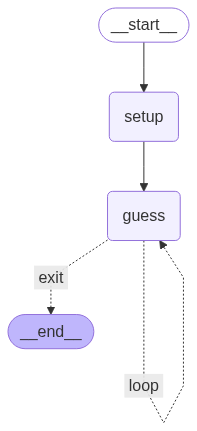

In [43]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [33]:
app.invoke({'player_name':'own_the_net', 'guesses':[], "attempts":0,"lower_bound":1, "upper_bound":20})

You Won!! Correct lottery number


{'player_name': 'Player Name: own_the_net',
 'guesses': [9],
 'attempts': 1,
 'lower_bound': 1,
 'upper_bound': 20}

In [44]:
app.invoke({'player_name':'own_the_net', 'guesses':[], "attempts":0,"lower_bound":1, "upper_bound":20})

Attempts Exceeded Failed!!


{'player_name': 'Player Name: own_the_net',
 'guesses': [6, 17, 10, 15, 17, 18],
 'attempts': 6,
 'lower_bound': 1,
 'upper_bound': 20}